# Практика 1: PyTorch и Lightning

## 1. Установка и импорты

In [ ]:
!pip install numpy matplotlib 

In [ ]:
# Установка torch без CUDA
!pip install torch

In [ ]:
# Установка torch с поддержкой CUDA (для GPU), нужно для GPU от NVIDIA
# pip install torch --index-url https://download.pytorch.org/whl/cu118

In [ ]:
# Установка lightning
!pip install lightning

In [ ]:
lightning.pytorch != pytorch.lightning

Импортируем все что нужно

In [34]:
import os
import random
import tqdm

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


## Воспроизводимость экспериментов
В машинном обучении важно фиксировать случайность, потому что иначе мы не сможем честно сравнивать результаты экспериментов

In [35]:
SEED = 239

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Выбор девайса для обучения
Выбор девайса зависит от текущего железа и установленной версии torch

Если доступна видеокарта NVIDIA и установлена версия torch с CUDA, то можно использовать 

```python 
device = "cuda"
```

Если вы обучаете на M-чипах от Apple, то можно использовать 

```python
device = "mps"
```

В ином случае используйте обучайте на CPU:
```python
device = "cpu"
```

In [ ]:
# device = "cuda" if torch.cuda.is_available() else "cpu"
device = "mps" if torch.backends.mps.is_available() else "cpu"
# device = "cpu"

device = torch.device(device)  # на самом деле, эта строка не обязательна, так как везде, где мы передаем device, будет происходить кast к torch.device

## 2. Построение моделей в torch

Построение моделей в PyTorch происходит с помощью специальных блоков - `nn.Module`. Это могут быть, например, слои нейронной сети. 

Для большинства слоёв, в torch уже созданы свои собственные блоки

In [ ]:
linear_layer = nn.Linear(in_features=10, out_features=5)
conv_layer = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)

relu_activation = nn.ReLU()
silu_activation = nn.SiLU()

# помимо слоёв, есть уже полноценные архитектуры
rnn_model = nn.RNN(input_size=10, hidden_size=20, num_layers=2, batch_first=True)
lstm_model = nn.LSTM(input_size=10, hidden_size=20, num_layers=2, batch_first=True)
transformer_model = nn.Transformer(d_model=512, nhead=8, num_encoder_layers=6, num_decoder_layers=6)

Наследуясь от `nn.Module`, мы можем создавать свои собственные модели

In [ ]:
class CustomMLP(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, output_size: int):
        super().__init__()
        self.linear1 = nn.Linear(input_size, hidden_size)
        self.activation = nn.ReLU()
        self.linear2 = nn.Linear(hidden_size, output_size)

        self.layers = [
            nn.Linear(input_size, hidden_size),
            nn.Linear(hidden_size, output_size)
        ]

        # Пример как делать не стоит:
        # self.layers = [nn.Linear(10, 10)] * 3
        # почему?

        # Так лучше:
        # self.layers = [nn.Linear(10,10) for _ in range(10)]

    def forward(self, x):
        x = self.linear1(x)
        x = self.activation(x)
        x = self.linear2(x)
        return x

Также nn.Module позволяет реализовывать функции потерь

In [ ]:
mae_loss = nn.L1Loss()
mse_loss = nn.MSELoss()
cross_entropy_loss = nn.CrossEntropyLoss()


# Или напишем собственную функцию потерь:
class CustomLoss(nn.Module):
    """
    Пусть это будет лосс средневзвешенной суммы MSE и MAE, где вес alpha - это некоторый гиперпараметр

    custom_loss = alpha * mse_loss + (1 - alpha) * mae_loss
    """
    def __init__(self, alpha: float = 0.5):
        super().__init__()
        self.alpha = alpha

        self.mse_loss = nn.MSELoss()
        self.mae_loss = nn.L1Loss()

    def forward(self, y_pred, y_true):
        mse = self.mse_loss(y_pred, y_true)
        mae = self.mae_loss(y_pred, y_true)
        return self.alpha * mse + (1 - self.alpha) * mae

Разберемся подробнее, что такое `nn.Module`. 

`nn.Module` является базовой абстракцией для всех слоёв и моделей. Модуль хранит: 
- сами веса слоя (если они есть)
- буферы (`register_buffer`)
    
    Это тензоры, которые принадлежат модулю, но не являются обучаемыми параметрами

- подмодули

    Если внутри класса, наследованного от `nn.Module`, написать `self.layer = nn.Linear(...)`, то этот слой зарегистрируется как дочерний модуль. Благодаря этому его параметры и буферы войдут в общую модель, а методы, вызванные на родительском `nn.Module`, рекурсивно будут применяться на всех дочерних `nn.Module`


    Текущее состояние модуля определяет словарь `state_dict`. Там лежат все данные, которые определяют `nn.Module` в текущий момент времени (и там же внутри записываются `state_dict` дочерних модулей).


In [36]:
mlp = CustomMLP(10, 10, 10).to(device)
print(mlp.state_dict().keys())

odict_keys(['linear1.weight', 'linear1.bias', 'linear2.weight', 'linear2.bias'])


In [ ]:
mlp.to(device, dtype=torch.float16)  # переносит модель на девайс и меняет тип данных модели 
mlp.train() # переводит модель в режим обучения
mlp.eval() # переводит модель в режим инференса

Позже мы рассмотрим еще одну абстрацию, уже для реализации кастомных дифференцируемых операций внутри `nn.Module` - `torch.autograd.Function`

## 3. Обучение моделей в torch

Базовый пример обучения модели нейронной сети - обучение на MNIST.

Скачаем данные:

In [ ]:
!pip install torchvision

In [ ]:
!pip install pandas

In [37]:
from torchvision import datasets, transforms

transform = transforms.ToTensor()  # преобразуем данные. Конкретно здесь - переводим PIL Image в тензор и нормализуем пиксели в диапазон [0, 1]

mnist_train_full = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
mnist_test_full = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

Выполним разделение на train/val/test и подготовим датасеты с помощью класса `Dataset`

`Dataset` - базовая абстракция для работы с данными в `torch`. Если мы хотим создать собственный класс датасета, надо наследоваться от него.

В классе, наследованном от `Dataset` необходимо реализовать два метода:
- `__len__` - метод, который возвращает количество объектов в датасете
- `__getitem__` - метод, который возвращает одни объект по индексу

При инициализации датасета, в методе `__init__`, мы можем либо скачать данные, либо подготовить сделать ссылку на них.

In [38]:
from torch.utils.data import Subset

train_ds_mnist = Subset(mnist_train_full, list(range(10000)))       # возьмем только 10к примеров для обучения, чтобы было быстрее
val_ds_mnist = Subset(mnist_train_full, list(range(10000, 12000)))  # выделим 2к примеров для валидации
test_ds_mnist = Subset(mnist_test_full, list(range(2000)))          # и столько же для теста

len(train_ds_mnist), len(val_ds_mnist), len(test_ds_mnist)

(10000, 2000, 2000)

Создадим даталоадеры. `Dataloader` - это абстракция для организации загрузки данных из датасета. 

Даталоадер отвечает за формирование батчей, перемешивание объектов и параллельную загрузку данных с диска в оперативную память. 

При реализации кастомного даталоадера необходимо наследоваться от `Dataloader`. Обычно, такой класс создают редко, поскольку базового функционала вполне достаточно. Кастомный класс даталоадера имеет смысл реализовывать тогда, когда нужна какая то нестандартная логика загрузки данных или формирования батчей. 

В этом случае необходимо переопределить такие методы, как:
- `__iter__` - метод, необходимый для итерации по даталоадеру (здесь же можно переопределить логику создания батчей)
- `__len__` - метод, который как и такой же метод в `Dataset`, возвращает количество батчей

Другой способ - переопределить `collate_fn`

In [39]:
train_loader_mnist = DataLoader(train_ds_mnist, batch_size=256, shuffle=True)
val_loader_mnist = DataLoader(val_ds_mnist, batch_size=256, shuffle=False)
test_loader_mnist = DataLoader(test_ds_mnist, batch_size=256, shuffle=False)

Посмотрим на данные

In [40]:
x_batch, y_batch = next(iter(train_loader_mnist))
print("x shape:", x_batch.shape)
print("y shape:", y_batch.shape)
print("classes:", sorted(set(y_batch.tolist())))

x shape: torch.Size([256, 1, 28, 28])
y shape: torch.Size([256])
classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [42]:
x = nn.Flatten()(x_batch)
print("x shape:", x.shape)


x shape: torch.Size([256, 784])


Напишем модель, которую будем обучать

In [ ]:
class MNISTMLP(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, output_size: int):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear1 = nn.Linear(input_size, hidden_size)
        self.activation = nn.ReLU()
        self.linear2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.flatten(x)
        x = self.linear1(x)
        x = self.activation(x)
        x = self.linear2(x)
        return x

И, наконец, обучим ее:

In [43]:
def train_one_epoch_mnist(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for x, y in tqdm.tqdm(loader, desc="train"):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_count += x.size(0)

    return total_loss, total_correct / total_count


@torch.no_grad()
def evaluate_mnist(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for x, y in tqdm.tqdm(loader, desc="eval"):
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_count += x.size(0)

    return total_loss, total_correct / total_count


def fit_mnist(model, optimizer, train_loader, val_loader, criterion, device, epochs=2):
    history = []

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch_mnist(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate_mnist(model, val_loader, criterion, device)

        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "train_acc": train_acc,
                "val_loss": val_loss,
                "val_acc": val_acc,
            }
        )

        print(
            f"epoch={epoch:02d} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
            f"| val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
        )

    return history

In [44]:
mlp = MNISTMLP(input_size=28*28*1, hidden_size=256, output_size=10).to(device)
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

history = fit_mnist(mlp, optimizer, train_loader_mnist, val_loader_mnist, criterion, device, epochs=20)

eval: 100%|██████████| 8/8 [00:00<00:00, 83.46it/s]


epoch=01 | train_loss=44.0959 train_acc=0.7630 | val_loss=3.7144 val_acc=0.8750


eval: 100%|██████████| 8/8 [00:00<00:00, 68.02it/s]


epoch=02 | train_loss=15.7423 train_acc=0.8916 | val_loss=2.7057 val_acc=0.9080


eval: 100%|██████████| 8/8 [00:00<00:00, 93.84it/s]


...

epoch=18 | train_loss=2.8787 train_acc=0.9818 | val_loss=1.4786 val_acc=0.9490


eval: 100%|██████████| 8/8 [00:00<00:00, 97.61it/s]


epoch=19 | train_loss=2.4419 train_acc=0.9851 | val_loss=1.4740 val_acc=0.9515


eval: 100%|██████████| 8/8 [00:00<00:00, 94.73it/s]

epoch=20 | train_loss=2.2971 train_acc=0.9866 | val_loss=1.4907 val_acc=0.9510


Нарисуем графики

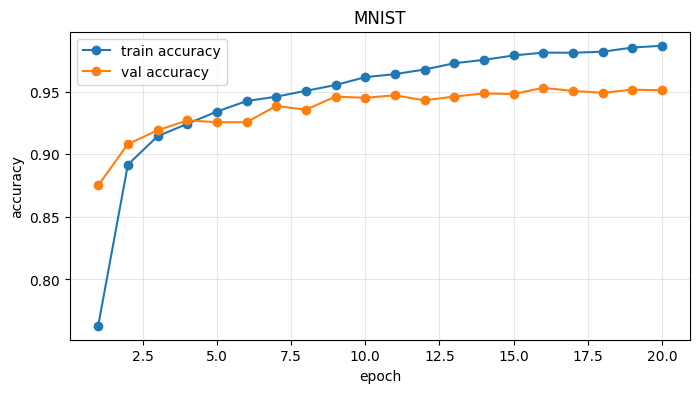

In [45]:
import pandas as pd
import matplotlib.pyplot as plt


history_df = pd.DataFrame(history)

plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["train_acc"], marker="o", label="train accuracy")
plt.plot(history_df["epoch"], history_df["val_acc"], marker="o", label="val accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("MNIST")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## 4. Обучение моделей в lightning

Код обучения, сбора и агрегации метрик, логирования, конфигурирования запуска экспериментов и многого другого редко когда сильно меняется из проекта в проект. 

Чтобы минимизировать написание этой рутины, используются различные фреймворки, один из которых - `lightning`.

`lightning` - это надстройка над `torch` более высокого уровня абстракции. 

Если в чистом `torch` мы обычно вручную пишем цикл обучения по эпохам и батчам, отдельно описываем валидацию, сбор и логирование метрик, сохранение чекпоинтов и настройку девайсов, то в `lightning` эта логика уже реализована за нас (нужно только ее настроить)

`lighting` разлеляет с помощью собственных абстракций:
- логику работы с данными
- логику модели и логику шага обучения
- логику инфраструктуры обучения


In [ ]:
from lightning import LightningDataModule, LightningModule, Trainer

Первая абстракция - это `LightningDataModule`, модуль для работы с данными.

Если `Dataset` обычно отвечает за доступ к отдельным объектам датасета, а `DataLoader` - за сбор этих объектов в батчи и параллельную загрузку данных, то `LightningDataModule` организует весь пайплайн работы с данными целиком.

В наследуемом от `LightningDataModule` классе реализуются следующие методы:
- `prepare_data` - скачивание данных, их подготовка и тд. То, что выполняется один раз
- `setup` - создание `Dataset` и разбиение на train/val/test подвыборки
- `train_dataloader` - создание `Dataloader` train-выборки
- `val_dataloader` - создание `Dataloader` val-выборки
- `test_dataloader` - создание `Dataloader` test-выборки
- `predict_dataloader` - создание `Dataloader` для инференса

In [46]:
class CustomLightningDataModule(LightningDataModule):
    def __init__(self, batch_size: int = 256):
        super().__init__()
        self.batch_size = batch_size
        self.transform = transforms.ToTensor()

    def prepare_data(self):
        datasets.MNIST(root="./data", train=True, download=True)
        datasets.MNIST(root="./data", train=False, download=True)

    def setup(self, stage=None):
        mnist_train_full = datasets.MNIST(root="./data", train=True, download=False, transform=self.transform)
        mnist_test_full = datasets.MNIST(root="./data", train=False, download=False, transform=self.transform)

        self.train_ds = Subset(mnist_train_full, list(range(10000)))
        self.val_ds = Subset(mnist_train_full, list(range(10000, 12000)))
        self.test_ds = Subset(mnist_test_full, list(range(2000)))

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=self.batch_size, shuffle=False)

    def test_dataloader(self):
        return DataLoader(self.test_ds, batch_size=self.batch_size, shuffle=False)

    def predict_dataloader(self):
        return DataLoader(self.test_ds, batch_size=self.batch_size, shuffle=False)


In [47]:
data_module = CustomLightningDataModule(batch_size=256)

Вторая абстракция - это `LightningModule`. Это обёртка над `nn.Module`, но расширенная сущностями, связанными с шагом обучения.

Внутри `LightningModule` обычно определяют:
- `forward` - прямой проход модели (как и в `nn.Module`)
- `configure_optimizers` - создание и настройка оптимизаторов и lr schedule
- `training_step` - что происходит на одном шаге обучения
- `validation_step` - что происходит на одном шаге валидации
- `test_step` - шаг тестирования
- `predict_step` - шаг инференса

Класс `LightningModule` наследуется от `nn.Module`, так что он повторяет все поведение `nn.Module`

In [48]:
class CustomLightningModule(LightningModule):
    def __init__(self, input_size: int = 28 * 28, hidden_size: int = 256, output_size: int = 10, lr: float = 1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.model = MNISTMLP(input_size=input_size, hidden_size=hidden_size, output_size=output_size)
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.model(x)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_acc", acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("val_acc", acc, on_step=False, on_epoch=True, prog_bar=True)

    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log("test_loss", loss)
        self.log("test_acc", acc)

    def predict_step(self, batch, batch_idx):
        x, _ = batch
        logits = self(x)
        return logits.argmax(dim=1)


In [49]:
model = CustomLightningModule()

Третья абстракция - `Trainer` (абстракция больше в инженерном смысле, в отличие от `LightningModule` и `nn.Module`, `Trainer` - не абстрактный класс). 

Этот класс берет на себя выполнение цикла обучения и инфраструктуры. Именно `Trainer` ответственнен за:
- запуск фаз обучения, валидации и инференса
- работу с девайсами (в том числе и распределенное обучение)
- работу со смешанной точностью (ее разберем позднее)
- чекпоинты
- логирование (мы также можем подключить внешние логгеры и системы мониторинга)
- дополнительный функционал в виде callback'ов

In [ ]:
trainer = Trainer(
    max_epochs=2,
    accelerator=device.type,
)

trainer.fit(model, datamodule=data_module)
trainer.test(model, datamodule=data_module)